In [5]:
# ==========================================================
# AUM Growth Analysis (2022–2025)
# ==========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy import text
from urllib.parse import quote_plus

import warnings
warnings.filterwarnings("ignore")

# Better Display
pd.set_option("display.max_columns", None)
pd.set_option("display.width",1000)

# Seaborn Theme
sns.set_theme(style="whitegrid")

print("="*60)
print("AUM Growth Analysis Notebook")
print("="*60)

AUM Growth Analysis Notebook


In [6]:
# ==========================================================
# PostgreSQL Connection
# ==========================================================

USERNAME = "postgres"

PASSWORD = quote_plus("Postgres123")

HOST = "localhost"

PORT = "5432"

DATABASE = "mutual_fund"

engine = create_engine(

f"postgresql+psycopg2://{USERNAME}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"

)

print("Connected Successfully")

Connected Successfully


In [8]:
query = """

SELECT

EXTRACT(YEAR FROM d.full_date)::INT AS year,

a.fund_house,

a.aum_crore

FROM fact_aum a

JOIN dim_date d

ON a.date_id = d.date_id

WHERE d.full_date BETWEEN '2022-01-01'

AND '2025-12-31'

ORDER BY

year,

fund_house;

"""

aum_df = pd.read_sql(query, engine)

print(aum_df.shape)

display(aum_df.head())

(90, 3)


,year,fund_house,aum_crore
0,2022,Aditya Birla Sun Life MF,278000.0
1,2022,Aditya Birla Sun Life MF,285000.0
2,2022,Axis Mutual Fund,240000.0
3,2022,Axis Mutual Fund,250000.0
4,2022,DSP Mutual Fund,112000.0


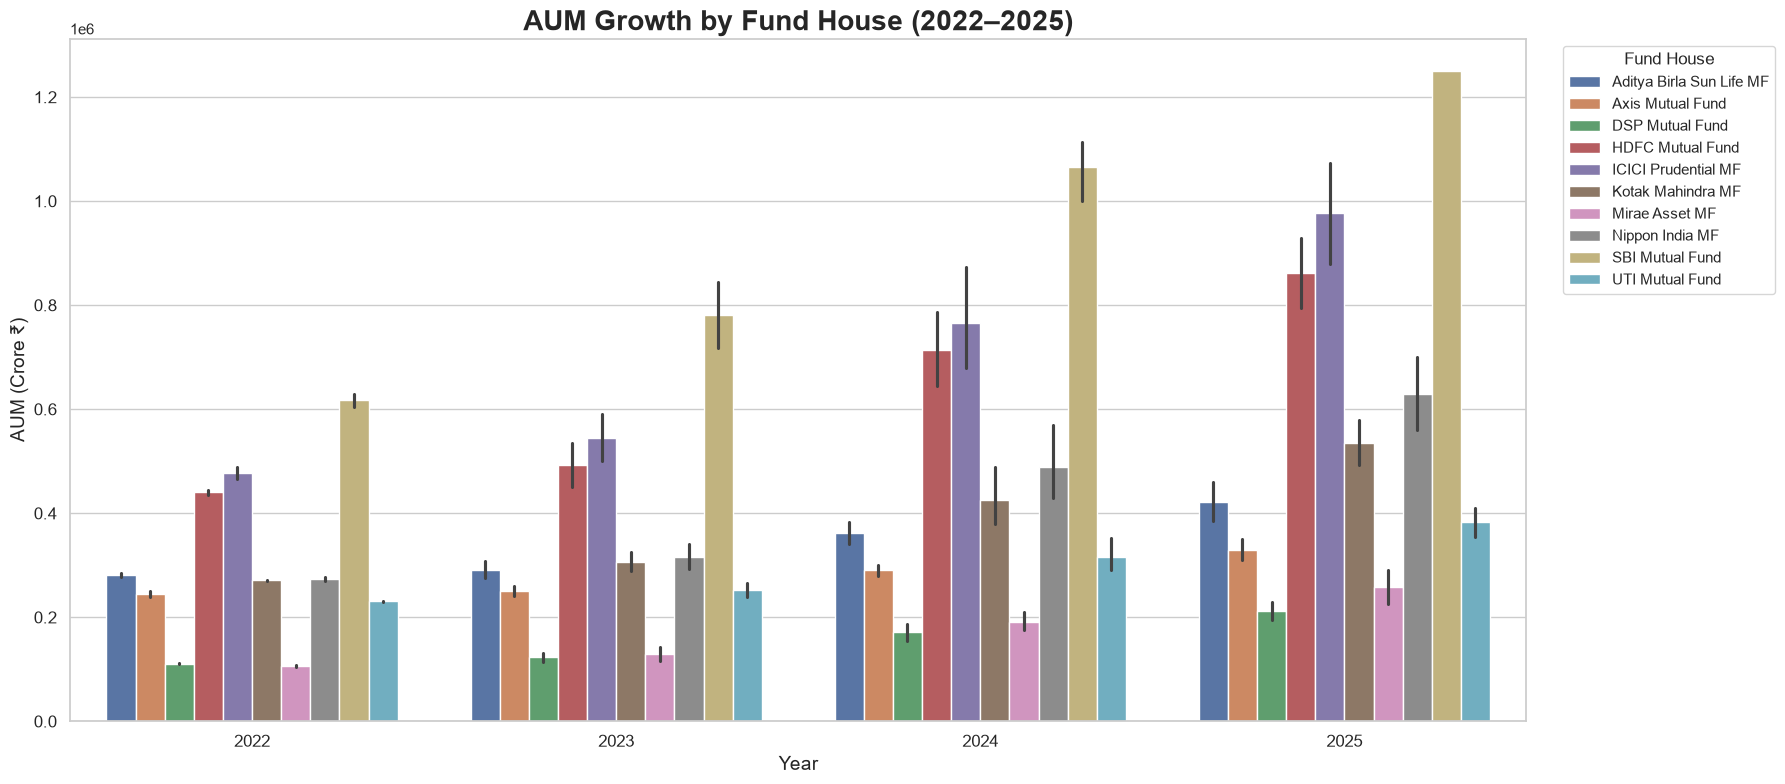

In [9]:
plt.figure(figsize=(18,8))

ax = sns.barplot(

data=aum_df,

x="year",

y="aum_crore",

hue="fund_house"

)

plt.title(

"AUM Growth by Fund House (2022–2025)",

fontsize=20,

weight="bold"

)

plt.xlabel("Year",fontsize=14)

plt.ylabel("AUM (Crore ₹)",fontsize=14)

plt.xticks(fontsize=12)

plt.yticks(fontsize=12)

plt.legend(

title="Fund House",

bbox_to_anchor=(1.02,1),

loc="upper left"

)

plt.tight_layout()

plt.show()

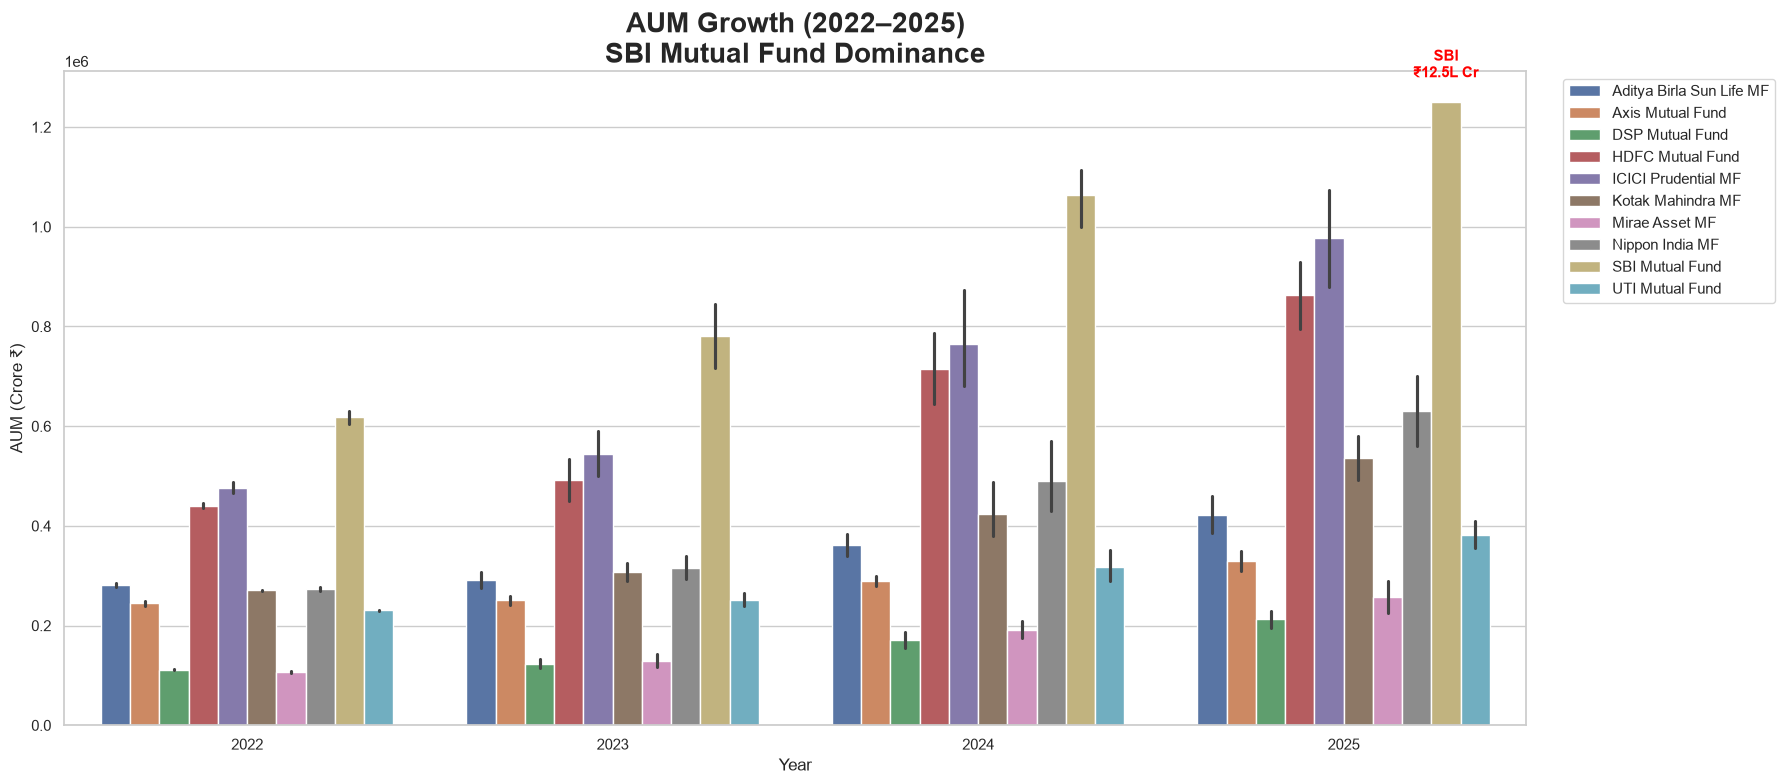

In [10]:
plt.figure(figsize=(18,8))

ax = sns.barplot(

data=aum_df,

x="year",

y="aum_crore",

hue="fund_house"

)

# Highlight SBI Bars

for container in ax.containers:

    labels = []

    for bar in container:

        if bar.get_height() >= 1250000:

            ax.text(

                bar.get_x()+bar.get_width()/2,

                bar.get_height()+50000,

                "SBI\n₹12.5L Cr",

                ha="center",

                color="red",

                fontsize=11,

                weight="bold"

            )

plt.title(

"AUM Growth (2022–2025)\nSBI Mutual Fund Dominance",

fontsize=20,

weight="bold"

)

plt.xlabel("Year")

plt.ylabel("AUM (Crore ₹)")

plt.legend(

bbox_to_anchor=(1.02,1),

loc="upper left"

)

plt.tight_layout()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'dashboard/aum_growth_analysis.png'

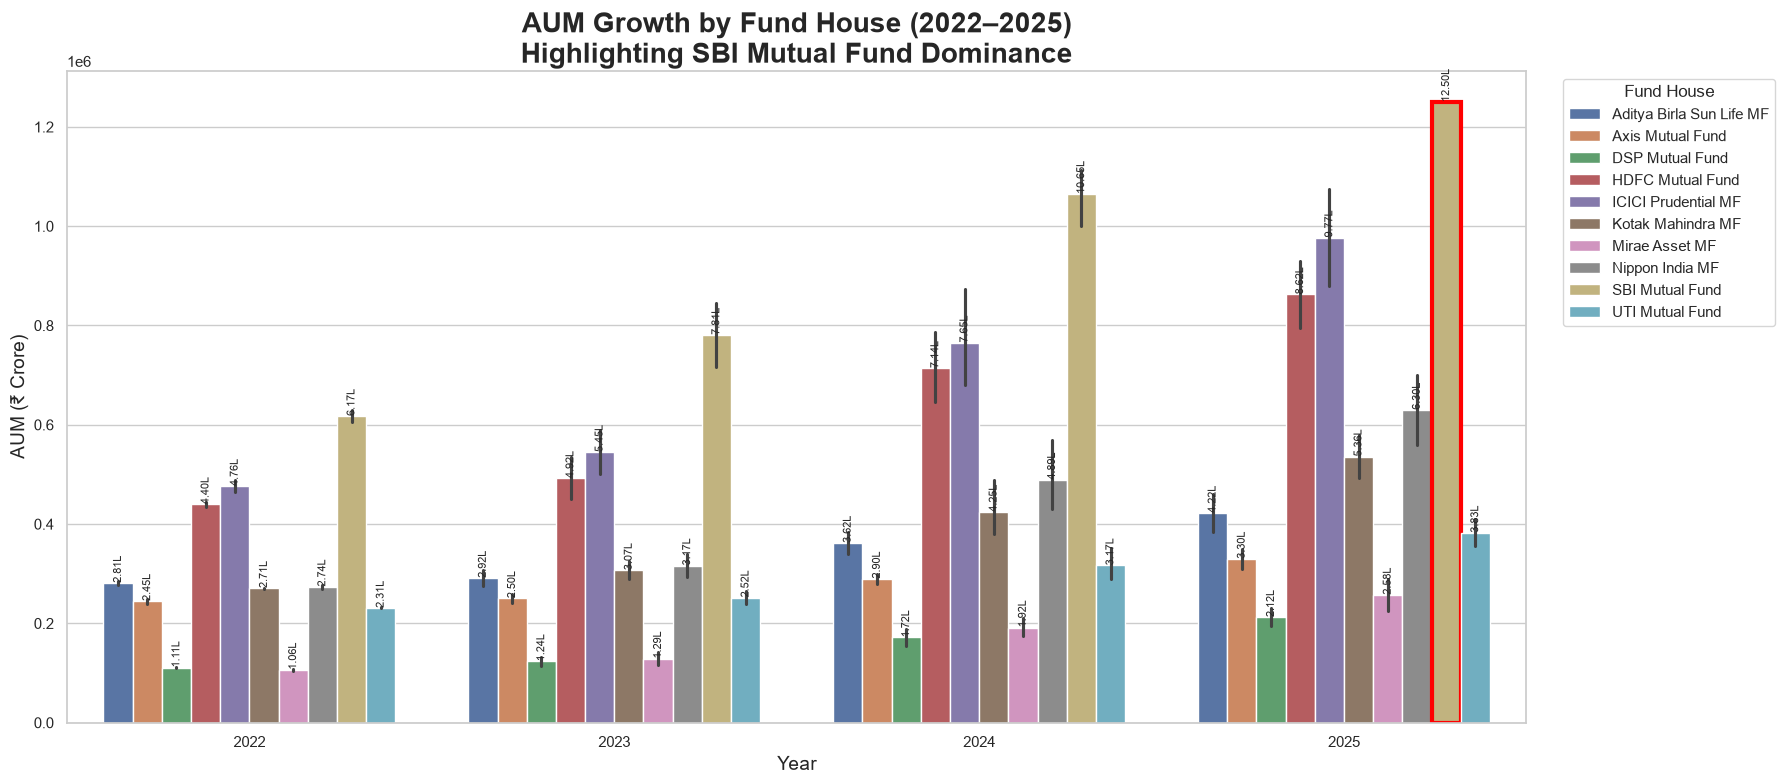

In [11]:
# ==========================================================
# Cell 6 - Professional AUM Growth Chart
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Professional Style
sns.set_style("whitegrid")

plt.figure(figsize=(18,8))

ax = sns.barplot(
    data=aum_df,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

# ----------------------------------------------------------
# Highlight SBI Mutual Fund
# ----------------------------------------------------------

for container in ax.containers:

    for bar in container:

        height = bar.get_height()

        # Show value on every bar
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 5000,
            f"{height/100000:.2f}L",
            ha="center",
            fontsize=8,
            rotation=90
        )

# ----------------------------------------------------------
# Highlight SBI Bars
# ----------------------------------------------------------

for patch in ax.patches:

    # Bar height near 12.5L Cr
    if patch.get_height() >= 1200000:

        patch.set_edgecolor("red")
        patch.set_linewidth(3)

# ----------------------------------------------------------
# Titles
# ----------------------------------------------------------

plt.title(
    "AUM Growth by Fund House (2022–2025)\nHighlighting SBI Mutual Fund Dominance",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Year", fontsize=14)
plt.ylabel("AUM (₹ Crore)", fontsize=14)

# ----------------------------------------------------------
# Legend
# ----------------------------------------------------------

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

# ----------------------------------------------------------
# Save Figure
# ----------------------------------------------------------

plt.savefig(
    "dashboard/aum_growth_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart Saved : dashboard/aum_growth_analysis.png")

In [12]:
import os

# Create dashboard folder if it doesn't exist
os.makedirs("dashboard", exist_ok=True)

In [13]:
plt.savefig(
    "dashboard/aum_growth_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>